# Titanic

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Data/titanic.xls')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


1. ML Task - This is a binary classification task since we are predicting wether a passenger survived or not (only 2 options)
2. Target varable - The target varable is the column 'Survived'
3. Unit of prediction - Each row represents one Passenger
4. What information is available at prediction time? - All of the features are available at prediction time except for the target variable Survived
5. Potential data leakage risks - There is no data leakage in this dataset
6. Evaluation metric - Accuracy as a baseline, and precision and recall for practice and ROC-AUC as a standard metric for binary classification

Check the shape of the dataset

In [4]:
df.shape

(891, 12)

The dataset has 891 rows and 12 columns

Check column names

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Check dtypes

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Check for missing values

In [7]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

The age column has 177 missing values, the cabin column has 687 missing values and the embarked column has 2 missing values

1. Age, SibSp, Parch and Fare are numeric columns
2. Survived, Pclass, Sex and Embarked are categorical columns
3. PassengerId, Name, Ticket and Cabin are identifiers

Is the target balanced or imbalanced?

In [8]:
df_survived = df['Survived'].value_counts(normalize=True).reset_index()
df_survived

,Survived,proportion
0,0,0.616162
1,1,0.383838


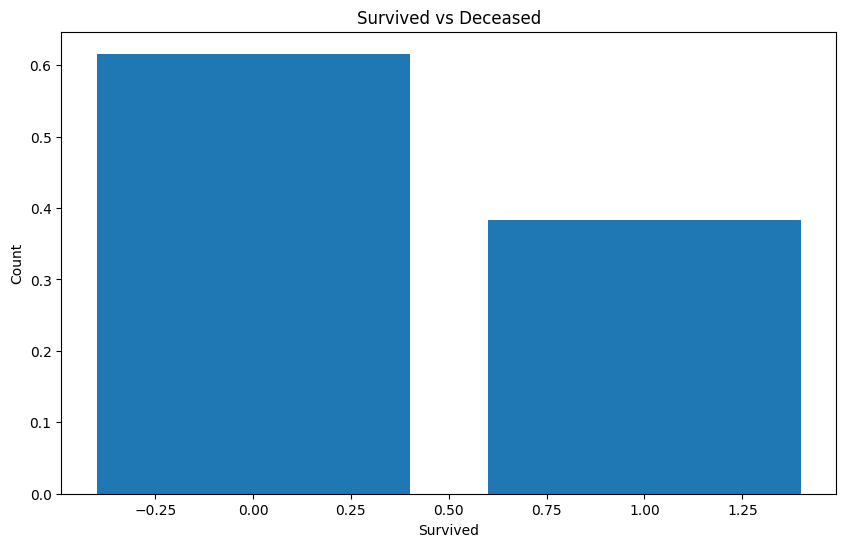

In [9]:
x = df_survived['Survived']
y = df_survived['proportion']

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_title('Survived vs Deceased')
ax.set_xlabel('Survived')
ax.set_ylabel('Count')
plt.show()

No, the target is not balanced with far more decesed passenger than survived

How does survival rate differ by sex?

In [10]:
df_survival_by_sex = pd.crosstab(df['Sex'], df['Survived'], normalize='index').reset_index()

In [11]:
df_survival_by_sex.head()

Survived,Sex,0,1
0,female,0.257962,0.742038
1,male,0.811092,0.188908


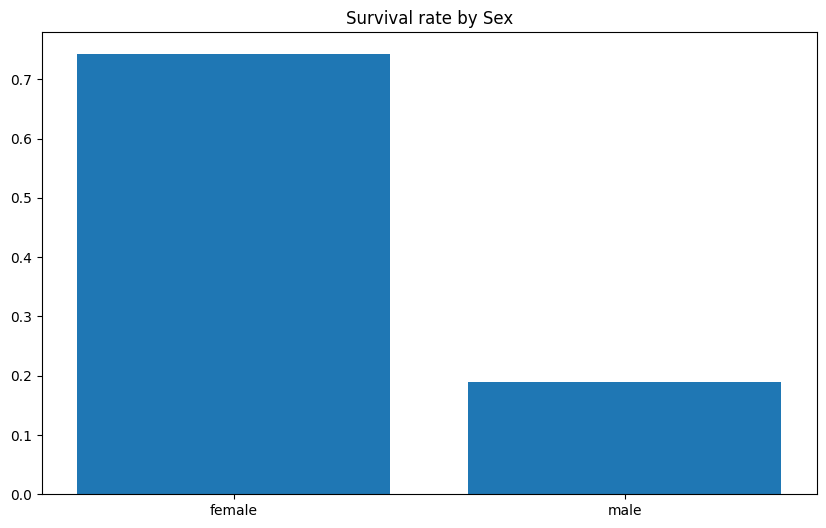

In [12]:
y = df_survival_by_sex[1]
x = df_survival_by_sex['Sex']

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_title('Survival rate by Sex')
plt.show()

More females survied than deceased while more men died than survived

How does survival rate differ by passenger class?

In [13]:
df_survival_by_class = pd.crosstab(df['Pclass'], df['Survived'],normalize='index').reset_index()
df_survival_by_class

Survived,Pclass,0,1
0,1,0.370370,0.629630
1,2,0.527174,0.472826
2,3,0.757637,0.242363


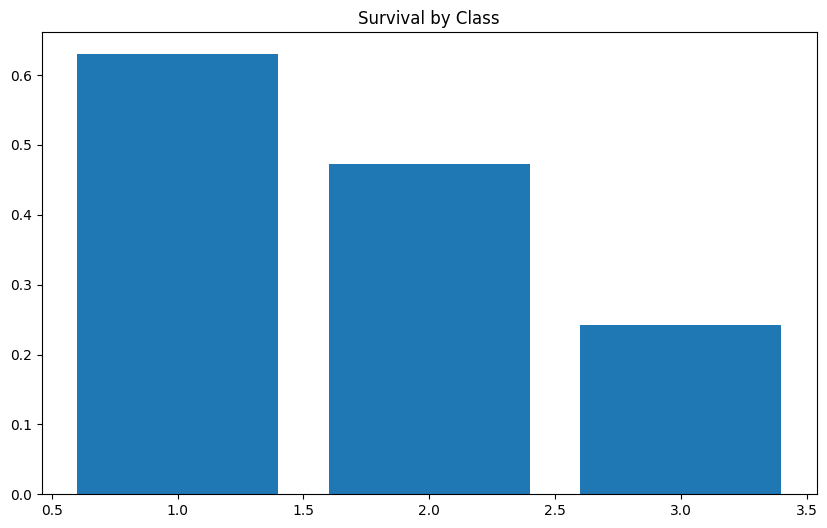

In [14]:
x = df_survival_by_class['Pclass']
y = df_survival_by_class[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_title('Survival by Class')
plt.show()

Class does influence the target variable, more people form the first class suvived than decesed, when for the third class more people deceased and less survived, for the second class the number is roughly the same with slighly more decised

Does Age influence survival?

In [15]:
bins = [0,12,18,35,50,65,100]
labels = ['Child','Teen','Young Adult','Adult','Middle Age','Senior']

In [16]:
df['binned_age'] = pd.cut(df['Age'],bins=bins, labels=labels)
df_by_age = pd.crosstab(df['binned_age'],df['Survived'],normalize='index').reset_index()
df_by_age

Survived,binned_age,0,1
0,Child,0.420290,0.579710
1,Teen,0.571429,0.428571
2,Young Adult,0.617318,0.382682
3,Adult,0.601307,0.398693
4,Middle Age,0.625000,0.375000
5,Senior,0.875000,0.125000


<function matplotlib.pyplot.show(close=None, block=None)>

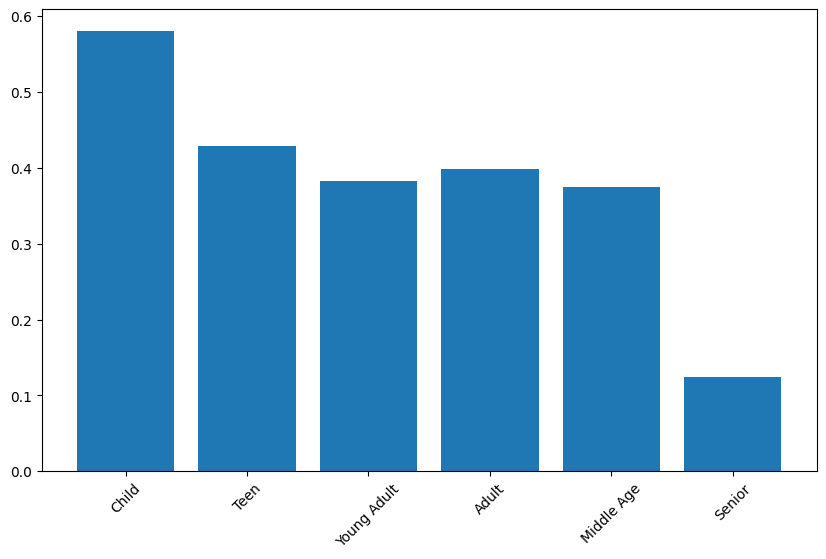

In [17]:
x = df_by_age['binned_age'].astype(str)
y = df_by_age[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
plt.xticks(rotation=45)
plt.show

Age influences survial rate mostly with children

Does fare correlate with survival?

In [18]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,binned_age
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,Young Adult


In [19]:
df['fare_binned'] = pd.qcut(df['Fare'], q=4, labels=['Low','Mid-Low','Mid-High','High'])
df_survival_by_fare = pd.crosstab(df['fare_binned'], df['Survived'], normalize='index').reset_index()
df_survival_by_fare

Survived,fare_binned,0,1
0,Low,0.802691,0.197309
1,Mid-Low,0.696429,0.303571
2,Mid-High,0.545045,0.454955
3,High,0.418919,0.581081


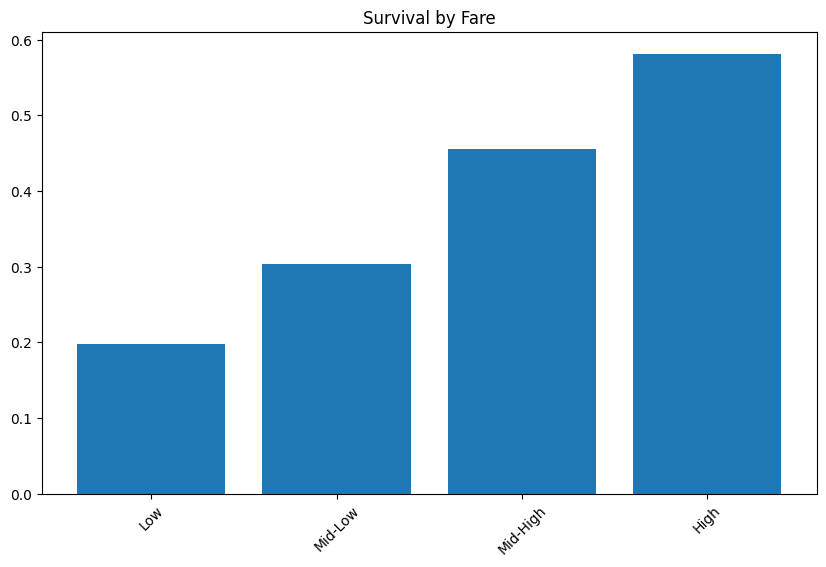

In [20]:
x = df_survival_by_fare['fare_binned'].astype(str)
y = df_survival_by_fare[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_title('Survival by Fare')
plt.xticks(rotation=45)
plt.show()

Fare does correlate with survival rate with High fare equals high survival rate.

In [21]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'binned_age',
       'fare_binned'],
      dtype='object')

Feature thinking:
1. Which feature should help predict survival? - Age, Class and Gender could all predict survival, could be used are SibSp, Parch, Fare and Embarked
2. Which feature should not? - PassengerId, Name, Ticket, Cabin
3. Which are risky (leakage/proxies)? - Fare could be a risky one because it is closely linked to Class, the better the class the more expensive the ticket (fare)
4. Which need transformation? - Class and gender could need transformation (one-hot encoding) age could be normalized

In [22]:
df = df[['Pclass','Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']]

In [23]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [24]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [25]:
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,FamilySize
0,3,male,22.0,1,0,7.2500,S,0,2
1,1,female,38.0,1,0,71.2833,C,1,2
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,1,2
4,3,male,35.0,0,0,8.0500,S,0,1


In [26]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [27]:
df.isna().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      2
Survived      0
FamilySize    0
dtype: int64

In [28]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

In [29]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [30]:
df['Fare_quantile'] = pd.qcut(df['Fare'], q=4, labels=[1,2,3,4])

In [31]:
df['Embarked_Q'] = df['Embarked_Q'].map({False:0, True:1})
df['Embarked_S'] = df['Embarked_S'].map({False:0, True:1})

In [32]:
df.head(1)

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived,FamilySize,Embarked_Q,Embarked_S,Fare_quantile
0,3,0,22.0,1,0,7.25,0,2,0,1,1


In [33]:
from sklearn.model_selection import train_test_split

In [34]:
x = df[['Pclass','Sex','Age','Fare_quantile','FamilySize','Embarked_Q','Embarked_S']]
y = df['Survived']

In [35]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=0)
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.8268156424581006

In [38]:
from sklearn.metrics import precision_score, recall_score

y_pred = model.predict(x_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
sensitivity = recall
specificity = recall_score(y_test, y_pred, pos_label=0)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Sensitivity: {sensitivity}')
print(f'Specificity: {specificity}')

Precision: 0.7377049180327869
Recall: 0.75
Sensitivity: 0.75
Specificity: 0.865546218487395


General metrics explanations:
1. Accuracy: How often is the model right overall
2. Precision: When it predicts a positive how often is it correct
3. Recall/Sensitivity: Of all positives, how many did the model catch
4. Specificity: Of all negatives, how many did the model catch
5. ROC-AUC: How well the model separates the two classes across a threshold

Metrics explanation for this specific case:
1. Percision: Of the passengers that the model predicted would survive, how many actually survived
2. Recall: Of all passengers who actually survived, how many did the model correctly identify
3. Specificity: Of all passengers who died, how many did the model correctly classify as deceased
4. ROC-AUC: measures how well the model separates survivors from non-survivors across all thresholds

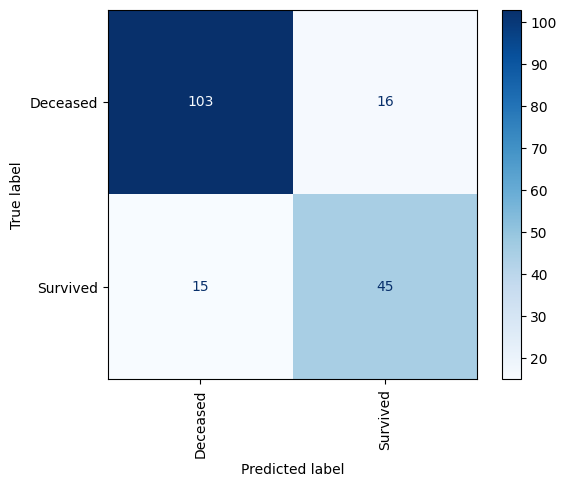

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd

cmd.from_estimator(model, x_test, y_test, display_labels=['Deceased', 'Survived'],
                   cmap='Blues', xticks_rotation='vertical')

Testing with a different combination of features

In [41]:
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived,FamilySize,Embarked_Q,Embarked_S,Fare_quantile
0,3,0,22.0,1,0,7.2500,0,2,0,1,1
1,1,1,38.0,1,0,71.2833,1,2,0,0,4
2,3,1,26.0,0,0,7.9250,1,1,0,1,2
3,1,1,35.0,1,0,53.1000,1,2,0,1,4
4,3,0,35.0,0,0,8.0500,0,1,0,1,2


In [43]:
x = df[['Pclass','Sex','Age']]
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [44]:
model = LogisticRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.7988826815642458

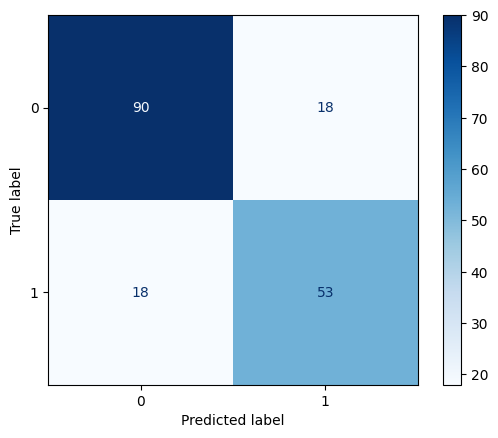

In [52]:
cmd.from_estimator(model, x_test, y_test, cmap='Blues')

In [50]:
from sklearn.metrics import precision_score, recall_score

y_pred = model.predict(x_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = recall_score(y_test, y_pred, pos_label=0)

print(f'Precision: {precision}')
print(f'Recall/Sensitivity: {recall}')
print(f'Specificity: {specificity}')

Precision: 0.7464788732394366
Recall/Sensitivity: 0.7464788732394366
Specificity: 0.8333333333333334


In [53]:
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived,FamilySize,Embarked_Q,Embarked_S,Fare_quantile
0,3,0,22.0,1,0,7.2500,0,2,0,1,1
1,1,1,38.0,1,0,71.2833,1,2,0,0,4
2,3,1,26.0,0,0,7.9250,1,1,0,1,2
3,1,1,35.0,1,0,53.1000,1,2,0,1,4
4,3,0,35.0,0,0,8.0500,0,1,0,1,2


In [58]:
df['New_class'] = df['Pclass'].map({3:1,2:2,1:3})

In [59]:
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived,FamilySize,Embarked_Q,Embarked_S,Fare_quantile,New_class
0,3,0,22.0,1,0,7.2500,0,2,0,1,1,1
1,1,1,38.0,1,0,71.2833,1,2,0,0,4,3
2,3,1,26.0,0,0,7.9250,1,1,0,1,2,1
3,1,1,35.0,1,0,53.1000,1,2,0,1,4,3
4,3,0,35.0,0,0,8.0500,0,1,0,1,2,1


In [60]:
df['Sex_Class'] = df['Sex'] + df['New_class']

In [61]:
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived,FamilySize,Embarked_Q,Embarked_S,Fare_quantile,New_class,Sex_Class
0,3,0,22.0,1,0,7.2500,0,2,0,1,1,1,1
1,1,1,38.0,1,0,71.2833,1,2,0,0,4,3,4
2,3,1,26.0,0,0,7.9250,1,1,0,1,2,1,2
3,1,1,35.0,1,0,53.1000,1,2,0,1,4,3,4
4,3,0,35.0,0,0,8.0500,0,1,0,1,2,1,1


In [62]:
x = df[['Age','Sex_Class']]
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [63]:
model = LogisticRegression()
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.7877094972067039

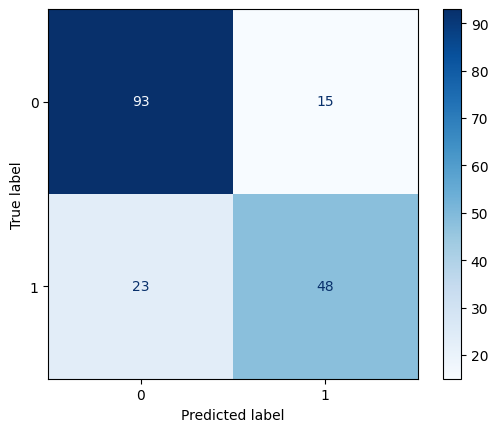

In [64]:
cmd.from_estimator(model,x_test,y_test,cmap='Blues')

In [66]:
y_pred = model.predict(x_test)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test, y_pred)
specificity = recall_score(y_test, y_pred, pos_label=0)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Specificity: {specificity}')

Precision: 0.7619047619047619
Recall: 0.676056338028169
Specificity: 0.8611111111111112


I first had to invert the classes because I want the higher value of the class to equal to a higher survival chance same for sex but that didn’t have to be inverted since it already follows the logic then by summing them up in a new feature we get a feature that the higher it is the higher the survival chance. This did not make the model better (looking at recall) but it did increase specificity which means that the model is better at predicting death.